In [1]:
#Cell 1 — load everything:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import joblib

from src.utils import load_config, set_seed, setup_plotting
from src.evaluation.plots import (
    plot_roc_curve, plot_pr_curve, plot_confusion_matrix, plot_model_comparison_bar
)

cfg = load_config()
set_seed(cfg["project"]["random_state"])
setup_plotting(cfg)

processed_dir = cfg["paths"]["processed_dir"]
models_dir = cfg["paths"]["models_dir"]

X_test_selected = pd.read_parquet(os.path.join(processed_dir, "X_test_selected.parquet"))
y_test = pd.read_parquet(os.path.join(processed_dir, "y_test.parquet"))["label_binary"]

final_model = joblib.load(os.path.join(models_dir, "final_model_random_forest.joblib"))

print("Loaded final model and test data:", X_test_selected.shape)

Loaded final model and test data: (44616, 20)


Figure saved: d:\MSc_Project\Network_IDS_Framework\results/figures\roc_curve_Final_RandomForest.png


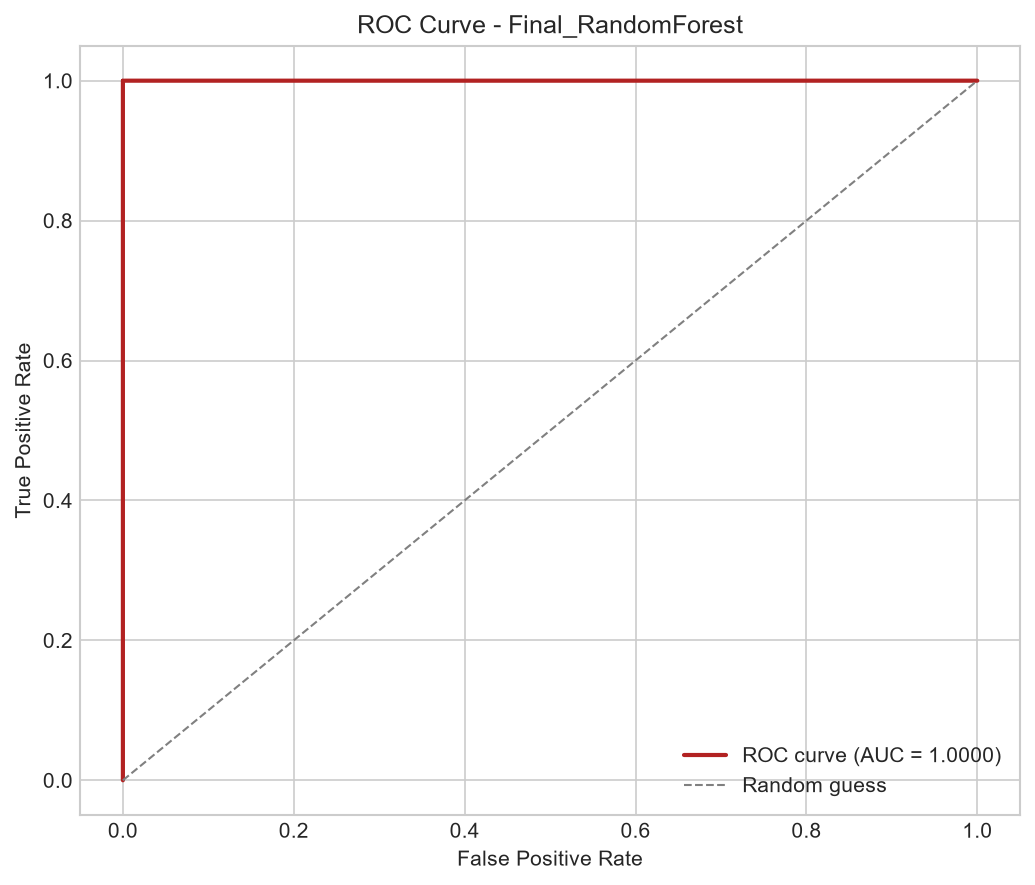

Figure saved: d:\MSc_Project\Network_IDS_Framework\results/figures\pr_curve_Final_RandomForest.png


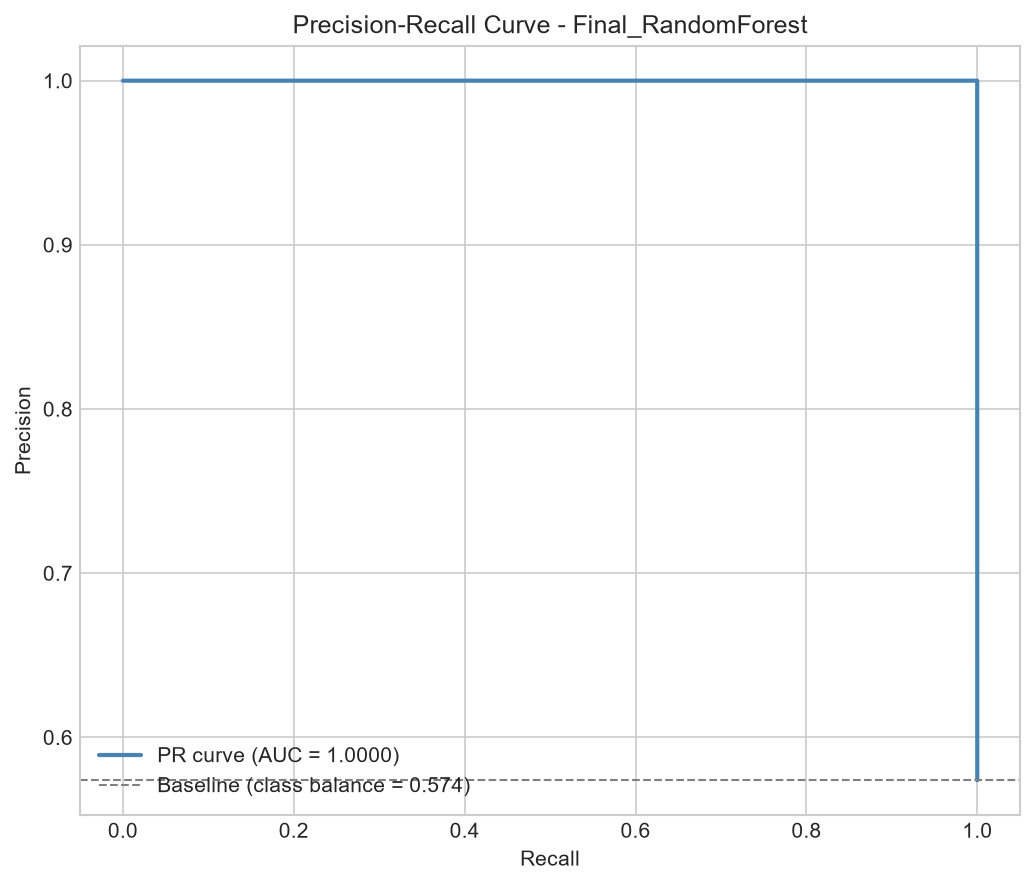

Figure saved: d:\MSc_Project\Network_IDS_Framework\results/figures\confusion_matrix_Final_RandomForest.png


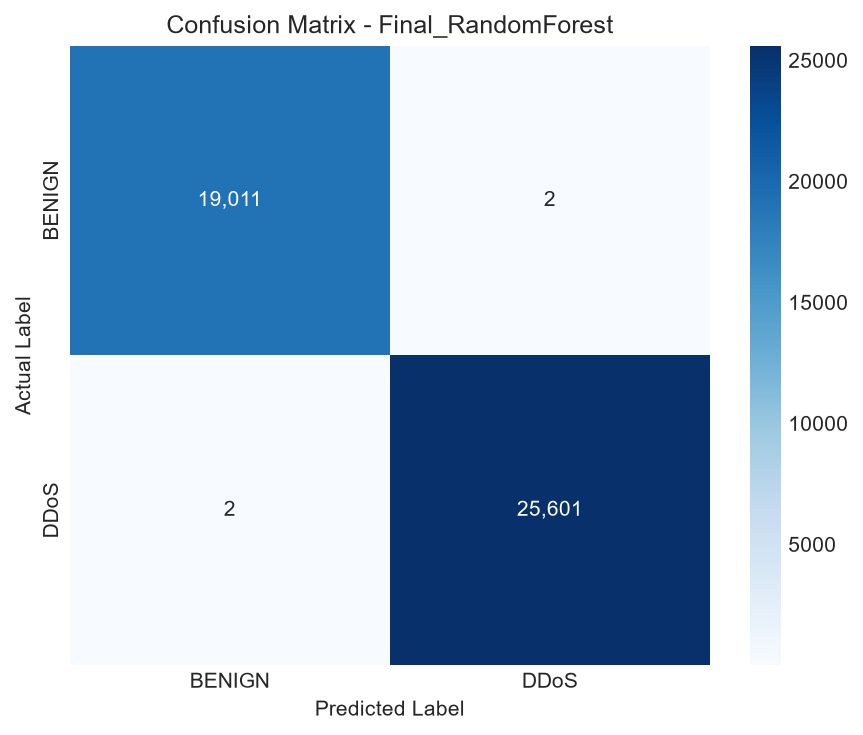

In [2]:
#Cell 2 — generate predictions + all three plots for the final model:
y_pred = final_model.predict(X_test_selected)
y_proba = final_model.predict_proba(X_test_selected)[:, 1]

roc_auc = plot_roc_curve(y_test, y_proba, "Final_RandomForest", cfg)
pr_auc = plot_pr_curve(y_test, y_proba, "Final_RandomForest", cfg)
plot_confusion_matrix(y_test, y_pred, "Final_RandomForest", cfg)

Figure saved: d:\MSc_Project\Network_IDS_Framework\results/figures\model_comparison_f1.png


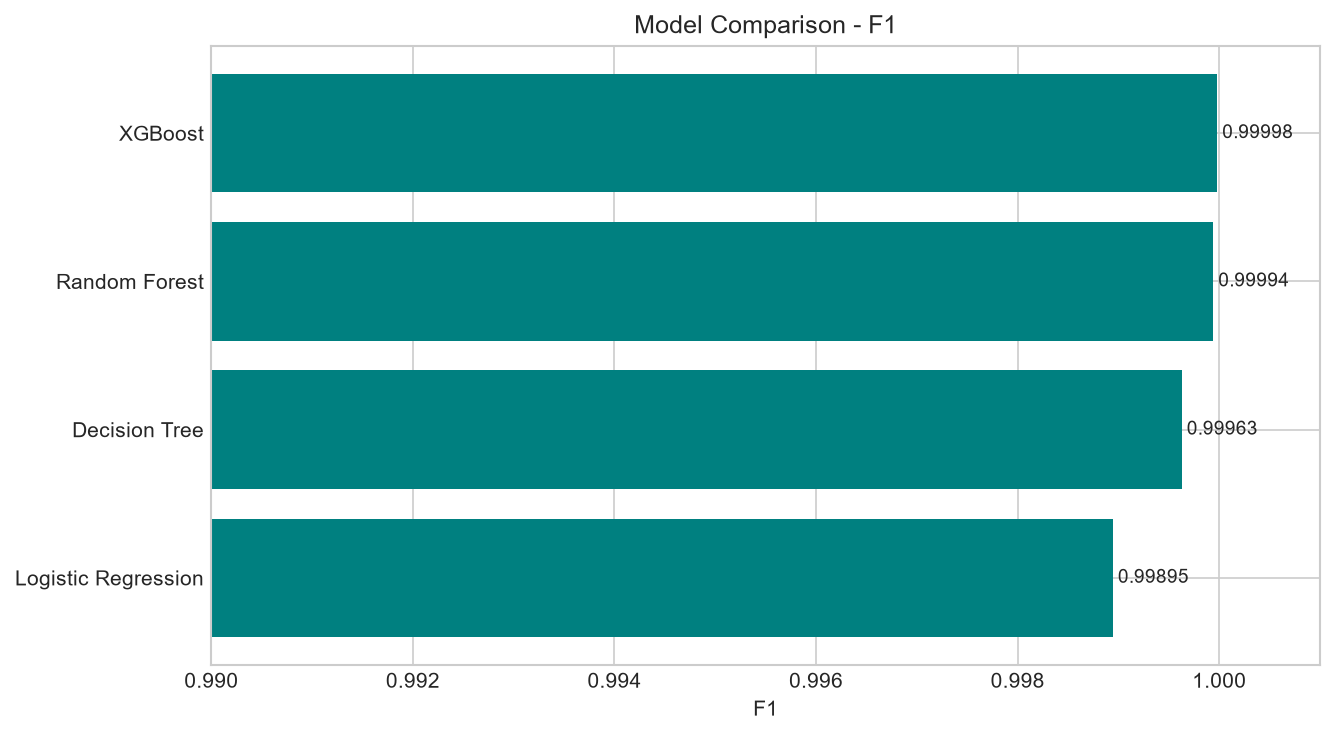

Figure saved: d:\MSc_Project\Network_IDS_Framework\results/figures\model_comparison_roc_auc.png


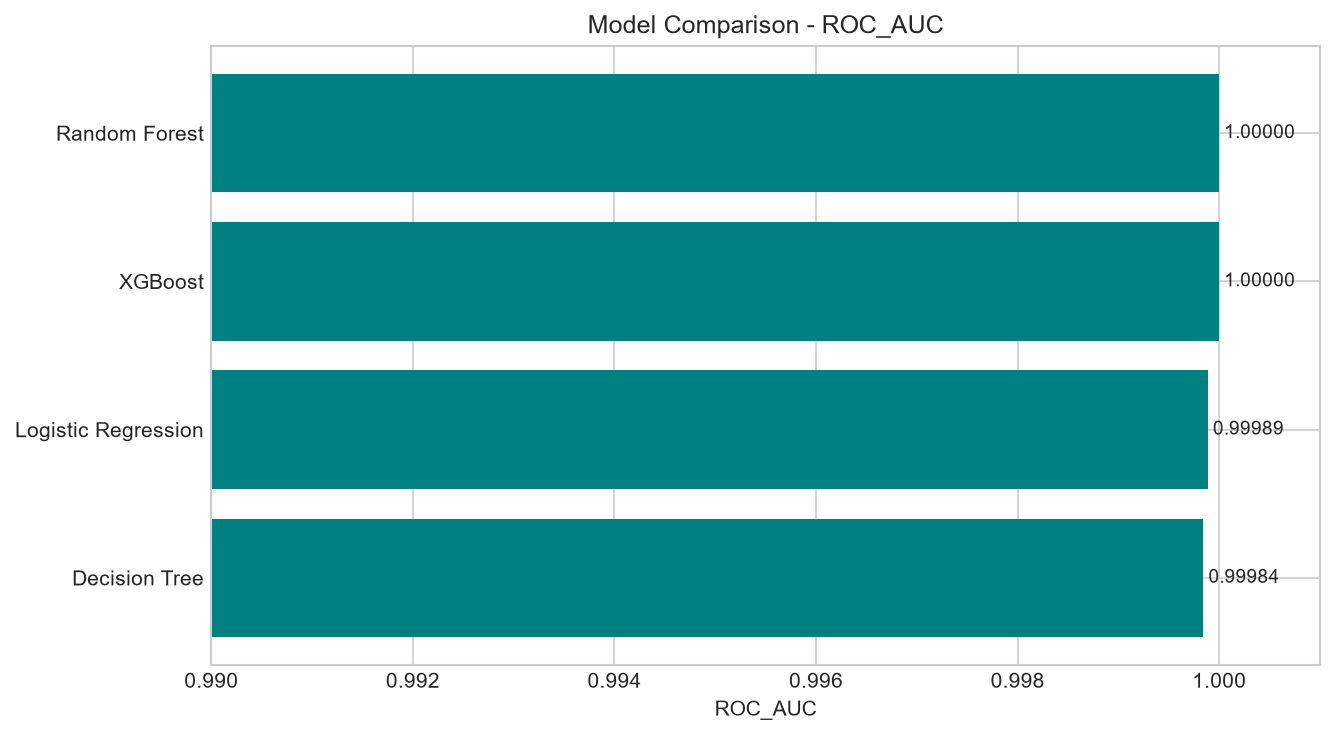

In [3]:
#Cell 3 — comparison bar chart across all models (loads your saved results table):
all_results = pd.read_csv(os.path.join(cfg["paths"]["metrics_dir"], "all_models_comparison.csv"))
plot_model_comparison_bar(all_results, metric="f1", cfg=cfg)
plot_model_comparison_bar(all_results, metric="roc_auc", cfg=cfg)

In [4]:
os.listdir(cfg["paths"]["figures_dir"])

['confusion_matrix_Final_RandomForest.png',
 'correlation_matrix.png',
 'model_comparison_f1.png',
 'model_comparison_roc_auc.png',
 'pr_curve_Final_RandomForest.png',
 'roc_curve_Final_RandomForest.png']

In [2]:
import pandas as pd
import json
import os

PROJECT_ROOT = r"D:\MSc_Project\Network_IDS_Framework"

with open(os.path.join(PROJECT_ROOT, "results", "reports", "selected_features.json")) as f:
    selection_info = json.load(f)
selected_features = selection_info["selected_features"]

X_test = pd.read_parquet(os.path.join(PROJECT_ROOT, "results", "processed", "X_test_selected.parquet"))
y_test = pd.read_parquet(os.path.join(PROJECT_ROOT, "results", "processed", "y_test.parquet"))["label_binary"]

# Grab 5 random rows - a mix, so the CSV has both classes
sample = X_test.sample(n=5, random_state=1)[selected_features]

# Save directly to your actual Desktop path (OneDrive-redirected)
output_path = r"C:\Users\ateeq\OneDrive\Desktop\test_upload_sample.csv"
sample.to_csv(output_path, index=False)

print("Saved to:", output_path)
print("\nTrue labels for these rows (for your reference, not in the file):")
print(y_test.loc[sample.index].map({0: "BENIGN", 1: "DDoS"}))

Saved to: C:\Users\ateeq\OneDrive\Desktop\test_upload_sample.csv

True labels for these rows (for your reference, not in the file):
71838       DDoS
217082    BENIGN
190234      DDoS
137304    BENIGN
214757    BENIGN
Name: label_binary, dtype: str
